# Policy Gradient for CartPole

## Overview

In previous tutorials we looked at **value-based** methods like DQN, which work by estimating
how good a state (or state-action pair) is. The policy is then derived *indirectly* from those
value estimates -- for example, by always choosing the action with the highest Q-value.

**Policy gradient** methods take a different approach: we directly parameterize a policy
$\pi_\theta(a \mid s)$ -- a function that maps states to action probabilities -- and use
gradient ascent to improve it. There is no separate value network; the policy *is* the thing
we are optimizing.

## The REINFORCE Algorithm

The specific algorithm implemented here is **REINFORCE** (Williams, 1992), one of the
foundational policy gradient methods. The procedure is:

1. Run the current policy in the environment to collect one or more complete trajectories
   (sequences of states, actions, and rewards).
2. For each time step $t$ in a trajectory, compute the **discounted future return**
   $G_t = \sum_{k=0}^{T-t} \gamma^k r_{t+k}$, i.e., the discounted sum of all rewards
   *from that time step onward*.
3. Update the policy parameters to increase the log-probability of actions that led to
   high returns and decrease it for actions that led to low returns.

The policy gradient theorem tells us the gradient of the expected return is:

$$\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_t \nabla_\theta \log \pi_\theta(a_t \mid s_t) \cdot G_t\right]$$

Because optimizers *minimize* by default, we will minimize the **negative** of this
quantity -- i.e., `loss = -log_prob * G_t`. We average over a small batch of trajectories
to reduce the variance of our gradient estimate.

---

### Installation

If you are running this notebook fresh, install the required packages first:

In [ ]:
# Run this cell once to install dependencies.
!pip install gymnasium torch matplotlib --quiet

## Imports

We use **Gymnasium** for the
CartPole environment, and **PyTorch** for building and training the neural network.

In [ ]:
import gymnasium as gym

import torch
from torch import nn
import torch.nn.functional as F
from torch.distributions import Bernoulli

import matplotlib.pyplot as plt

## The Policy Network

The policy network takes a 4-dimensional state vector (cart position, cart velocity,
pole angle, pole angular velocity) and outputs a *single probability* between 0 and 1.

CartPole has a **binary action space**: push left (0) or push right (1). Rather than
using a softmax over two outputs, we can model this more compactly with a single
sigmoid output $p$ and treat the action as a Bernoulli random variable:

- With probability $p$, we push right (action = 1).
- With probability $1 - p$, we push left (action = 0).

The architecture is a simple two-hidden-layer MLP with ReLU activations. The sigmoid
on the output squashes the final value into $[0, 1]$ so it can be interpreted as a
valid probability.

In [ ]:
class PolicyNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNet, self).__init__()

        self.input_dim = input_dim
        self.output_dim = output_dim

        self.fc1 = nn.Linear(self.input_dim, 32)
        self.fc2 = nn.Linear(32, 32)
        self.output = nn.Linear(32, self.output_dim)

    def forward(self, x):
        output = F.relu(self.fc1(x))
        output = F.relu(self.fc2(output))
        output = torch.sigmoid(self.output(output))
        return output

## Helper: NumPy Array to PyTorch Tensor

Gymnasium returns observations as NumPy arrays, but PyTorch needs tensors.
This small utility handles that conversion. We specify `dtype=torch.float32`
to match the default floating-point type used by PyTorch's `nn.Linear` layers.

In [ ]:
def to_tensor(arr):
    """Converts a numpy array to a float32 tensor."""
    return torch.tensor(arr, dtype=torch.float32)

## Environment Setup and Hyperparameters

We use `CartPole-v1`, which has a maximum episode length of 500 steps. The episode ends early if the
pole falls too far or the cart moves out of bounds.

A few things worth noting about the hyperparameters:

- **NUM_EPISODES**: how many gradient update steps we will perform. Each
  update uses a fresh batch of trajectory data.
- **GAMMA**: the discount factor. Values close to 1 (like 0.99) give nearly
  equal weight to near-future and far-future rewards.
- **BATCH_SIZE**: how many full trajectories we collect before each gradient
  step. Averaging over multiple trajectories reduces variance.
- **baseline**: subtracting a baseline from the returns does not change the
  expected gradient (it is an unbiased operation) but can significantly reduce
  variance. We start with a baseline of 0 (no baseline) for simplicity.
- **RMSprop**: a common adaptive learning rate optimizer that works well for
  policy gradient methods.

In [ ]:
# Define environment.
# CartPole-v1 has a maximum episode length of 500 steps.
env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]   # 4
action_dim = env.action_space.n              # 2 (left or right)
bernoulli_action_dim = 1  # We model the binary action with a single Bernoulli output.

# Initialize the policy network.
policy_net = PolicyNet(input_dim=state_dim, output_dim=bernoulli_action_dim)

# Hyperparameters
NUM_EPISODES = 500
GAMMA = 0.99
BATCH_SIZE = 5
LEARNING_RATE = 0.01

# Baseline for variance reduction. Set to 0 (no baseline) for now.
baseline = 0.0

# Optimizer
optimizer = torch.optim.RMSprop(policy_net.parameters(), lr=LEARNING_RATE)

## Training Loop

The training loop has two nested levels:

**Outer loop (over episodes):** Each episode corresponds to one gradient update.
Before updating, we collect a batch of BATCH_SIZE complete trajectories.

**Inner loop (over trajectories in the batch):** For each trajectory, we run the
current policy in the environment until the episode ends. At each time step we:

1. Feed the current state through the policy network to get action probability $p$.
2. Sample an action from `Bernoulli(p)`.
3. Execute the action and record the state, action, and discounted reward.

**Constructing the return $G_t$:**
After a trajectory ends, we compute the discounted future return at each time step.
Rather than using the full discounted sum from time 0 (which would include past
rewards that the current action could not have influenced), we use only the *future*
rewards from time $t$ onward. This is called the **reward-to-go** and is an important
variance-reduction trick.

Note that the discount factors have already been applied incrementally as we collected
the trajectory, so `sum(discounted_rewards[t:])` gives us
$\sum_{k=t}^{T} \gamma^{k-t_0} r_k$ where $t_0$ is the start of the episode.

**Gradient update:**
Once the batch is collected, we compute the policy gradient loss:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \pi_\theta(a_i \mid s_i) \cdot (G_i - b)$$

where $N$ is the total number of state-action pairs across all trajectories in the
batch, and $b$ is the baseline. Calling `.backward()` on this loss computes
$\nabla_\theta \mathcal{L}$, and the optimizer takes a step to minimize it --
which is equivalent to maximizing the expected return.

**Gymnasium API notes:**

- `env.reset()` returns a tuple `(observation, info)` instead of just an observation.
  We unpack with `state, _ = env.reset()`.
- `env.step()` returns a 5-tuple `(obs, reward, terminated, truncated, info)` instead
  of 4. An episode is done when either `terminated` (pole fell) or `truncated`
  (time limit reached) is `True`.

**Note: This training process may take 5-10 minutes to run on Google Colab CPU.**

In [ ]:
# Collect average trajectory rewards for plotting.
traj_reward_history = []

for ep_i in range(NUM_EPISODES):

    # These lists will hold data from all trajectories in this batch.
    states = []
    actions = []
    rewards = []
    cumulative_undiscounted_reward = 0.0

    # --- Collect a batch of BATCH_SIZE trajectories ---
    for traj_i in range(BATCH_SIZE):
        time_step = 0
        done = False

        # Gymnasium reset() returns (observation, info).
        cur_state, _ = env.reset()
        cur_state = to_tensor(cur_state)

        discount_factor = 1.0
        discounted_rewards = []

        while not done:
            # Forward pass: get action probability from the current policy.
            action_prob = policy_net(cur_state)

            # Sample an action from Bernoulli(p).
            action_sampler = Bernoulli(probs=action_prob)
            action = int(action_sampler.sample().item())

            # Store state and action for the gradient update later.
            states.append(cur_state)
            actions.append(action)

            # Gymnasium step() returns (obs, reward, terminated, truncated, info).
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Apply the running discount factor and record.
            discounted_rewards.append(reward * discount_factor)
            cumulative_undiscounted_reward += reward

            cur_state = to_tensor(next_state)
            time_step += 1
            discount_factor *= GAMMA

        # Construct the discounted future return (reward-to-go) at each time step.
        # G_t = sum of discounted_rewards from index t to end of trajectory.
        for time_i in range(time_step):
            rewards.append(sum(discounted_rewards[time_i:]))

    # --- Gradient update ---
    avg_traj_reward = cumulative_undiscounted_reward / BATCH_SIZE
    traj_reward_history.append(avg_traj_reward)

    if (ep_i + 1) % 10 == 0:
        print("Episode {}: Average reward per trajectory = {:.1f}".format(
            ep_i + 1, avg_traj_reward))

    optimizer.zero_grad()
    data_len = len(states)
    loss = 0.0

    # For each stored (state, action, return) triple, compute the policy gradient loss.
    # We re-run the forward pass so PyTorch can build a computation graph through the
    # current network parameters.
    for data_i in range(data_len):
        action_prob = policy_net(states[data_i])
        action_sampler = Bernoulli(probs=action_prob)
        log_prob = action_sampler.log_prob(torch.tensor([float(actions[data_i])]))
        loss -= log_prob * (rewards[data_i] - baseline)

    loss /= float(data_len)
    loss.backward()
    optimizer.step()

Episode 10: Average reward per trajectory = 26.6
Episode 20: Average reward per trajectory = 34.0
Episode 30: Average reward per trajectory = 34.0
Episode 40: Average reward per trajectory = 55.8
Episode 50: Average reward per trajectory = 75.0
Episode 60: Average reward per trajectory = 88.4
Episode 70: Average reward per trajectory = 112.8
Episode 80: Average reward per trajectory = 90.8
Episode 90: Average reward per trajectory = 261.6
Episode 100: Average reward per trajectory = 76.4
Episode 110: Average reward per trajectory = 162.6
Episode 120: Average reward per trajectory = 209.8
Episode 130: Average reward per trajectory = 483.8
Episode 140: Average reward per trajectory = 240.6
Episode 150: Average reward per trajectory = 340.6
Episode 160: Average reward per trajectory = 500.0
Episode 170: Average reward per trajectory = 466.8
Episode 180: Average reward per trajectory = 462.6
Episode 190: Average reward per trajectory = 407.2
Episode 200: Average reward per trajectory = 500

## Results

After training, we close the environment and plot the average undiscounted reward
per trajectory over time. A reward of 500 means the pole was balanced for the
entire maximum episode length -- the task is considered solved.

You should see the reward climb from low values early on and eventually stabilize
near or at 500. Policy gradient methods can be noisier than DQN during training
because each gradient estimate is based on a small batch of sampled trajectories.

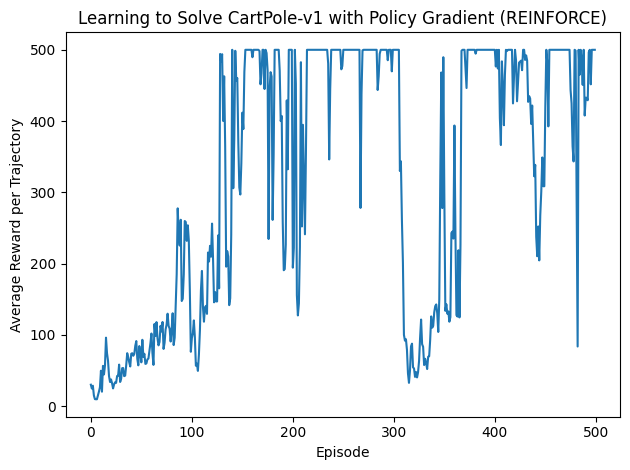

In [ ]:
env.close()

plt.figure()
plt.plot(traj_reward_history)
plt.title("Learning to Solve CartPole-v1 with Policy Gradient (REINFORCE)")
plt.xlabel("Episode")
plt.ylabel("Average Reward per Trajectory")
plt.tight_layout()
plt.savefig("CartPole-pg.png")
plt.show()
plt.close()

---

# Algorithm Insights: Pseudo-code and Worked Example

---


### (i) Pseudo-code

The REINFORCE algorithm can feel like a lot of moving parts when reading the code directly.
This section lays out exactly what is happening at each stage, in plain terms first and then
more precisely with the math.

---

**Given**

| Parameter | Value | Plain English |
|:---|:---|:---|
| State | $\mathbf{s} = [s_1, s_2, s_3, s_4]$, 4 real numbers | Cart position, cart velocity, pole angle, pole angular velocity |
| Actions | $\mathcal{A} = \{0, 1\}$ | 0 = push left, 1 = push right |
| Policy network | $\pi_\theta(\mathbf{s})$ | A neural net with weights $\theta$ that outputs a single number $p \in [0,1]$ |
| Discount factor | $\gamma = 0.99$ | How much we value future rewards relative to immediate ones |
| Learning rate | $\eta = 0.01$ | How big a step the optimizer takes each update |
| Batch size | $B = 5$ trajectories per update | How many full episodes we collect before each gradient step |
| Number of updates | 500 episodes | Total number of gradient update steps |
| Baseline | $b = 0$ | A value subtracted from returns to reduce variance (zero here for simplicity) |

---

**Initialize**

$$\theta \leftarrow \text{random small values} \qquad \texttt{traj_reward_history} \leftarrow [\,]$$

The policy network weights start out random. This means the network initially outputs a
probability close to 0.5 for nearly every state, so actions are essentially random at first.

---

**For each episode** $ep = 1 \ldots 500$:

Clear the batch storage: $\texttt{states} = [\,],\ \texttt{actions} = [\,],\ \texttt{rewards} = [\,]$

**Step 1 - Collect $B = 5$ trajectories using the current policy.**

For each trajectory $\tau = 1 \ldots B$:

&emsp; (a) Reset the environment: $\mathbf{s}_0 \leftarrow \texttt{env.reset()}$

&emsp; (b) Set $\texttt{discount_factor} = 1.0$,&ensp; $\texttt{discounted_rewards} = [\,]$

&emsp; (c) While the episode is not done, at each time step $t$:

&emsp;&emsp; **i.** Forward pass through the policy network. The 4-element state vector is
processed layer by layer through the MLP:

$$\mathbf{h}_1 = \text{ReLU}(W_1\,\mathbf{s}_t + \mathbf{b}_1) \in \mathbb{R}^{32}$$
$$\mathbf{h}_2 = \text{ReLU}(W_2\,\mathbf{h}_1 + \mathbf{b}_2) \in \mathbb{R}^{32}$$
$$p_t = \sigma(W_3\,\mathbf{h}_2 + b_3) \in [0,1]$$

&emsp;&emsp; The sigmoid $\sigma$ squashes the final linear output into $[0, 1]$, giving a valid
probability. The output $p_t$ is the probability the current policy assigns to "push right"
(action 1); the probability of "push left" (action 0) is $1 - p_t$.

&emsp;&emsp; **ii.** Sample an action from a Bernoulli distribution with that probability:
$$a_t \sim \text{Bernoulli}(p_t) \qquad \Rightarrow \qquad a_t = \begin{cases} 1 & \text{with prob } p_t \\ 0 & \text{with prob } 1-p_t \end{cases}$$

&emsp;&emsp; **iii.** Execute $a_t$ in the environment. Observe the next state $\mathbf{s}_{t+1}$,
reward $r_t$, and whether the episode is done.
CartPole gives a reward of $+1$ for every time step the pole stays upright.

&emsp;&emsp; **iv.** Save the current state and action to the batch lists:
$$\texttt{states.append}(\mathbf{s}_t), \qquad \texttt{actions.append}(a_t)$$
&emsp;&emsp; We save $\mathbf{s}_t$ (the state *before* the action), not $\mathbf{s}_{t+1}$, because
the policy chose $a_t$ based on $\mathbf{s}_t$.

&emsp;&emsp; **v.** Apply the running discount and record the discounted reward:
$$\texttt{discounted_rewards.append}(r_t \times \texttt{discount_factor})$$
$$\texttt{discount_factor} \leftarrow \texttt{discount_factor} \times \gamma$$
&emsp;&emsp; The discount factor starts at 1.0 and is multiplied by $\gamma$ once per step,
so a reward earned $k$ steps into the trajectory is scaled by $\gamma^k$.

&emsp;&emsp; **vi.** Advance to the next state:
$$\texttt{cur_state} \leftarrow \texttt{to_tensor}(\mathbf{s}_{t+1})$$
&emsp;&emsp; This overwrites the current state variable so the next loop iteration processes the
updated environment state. Without this step the policy would repeatedly act on the same
starting state and the trajectory would never progress.

&emsp; (d) Once the trajectory ends at step $T$, compute the **reward-to-go** at each time step:
$$G_t = \sum_{k=t}^{T} \texttt{discounted_rewards}[k]$$
&emsp; Append each $G_t$ to the $\texttt{rewards}$ list.

> **Why reward-to-go and not the total trajectory return?**
> The action taken at time $t$ can only have caused rewards *from* time $t$ onwards.
> It had no effect on rewards that already happened before $t$.
> Using reward-to-go instead of the full sum removes irrelevant past rewards from the
> gradient signal, which reduces variance and speeds up learning.

> **Note on discounting:** Because the discount factor accumulates from the start of the
> episode, each entry in `discounted_rewards` already carries the factor $\gamma^k$ from
> the absolute time step $k$. This means $G_t$ as computed here equals $\gamma^t$ times
> the "textbook" reward-to-go $\sum_{k=0}^{T-t}\gamma^k r_{t+k}$. The two are equivalent
> for learning purposes: multiplying every return by the same constant $\gamma^t$ does not
> change which actions are relatively better or worse, so the gradient still points in the
> right direction. The code's approach is simpler to implement because the discount factor
> only needs to be tracked as a single running scalar.

**Batch summary (after all $B$ trajectories have been collected):**

At this point all $B$ trajectories have been collected and reward-to-go computed for each.
The batch lists are now fully populated:

| List | Contents | Length |
|:---|:---|:---|
| $\texttt{states}$ | One tensor $\mathbf{s}_i$ per time step, all trajectories concatenated | $N$ |
| $\texttt{actions}$ | One integer $a_i \in \{0, 1\}$ per time step | $N$ |
| $\texttt{rewards}$ | One reward-to-go value $G_i$ per time step | $N$ |

$N$ is the total number of time steps across all $B$ trajectories. For example, if each of
the $B = 5$ trajectories lasted 50 steps, then $N = 250$.

**Step 2 - Zero out the gradient buffer.**

$$\texttt{optimizer.zero_grad()}$$

PyTorch accumulates gradients by default: each call to `.backward()` *adds* new gradient
values on top of whatever was already stored from previous updates. Before computing this
batch's gradient we must clear that buffer. Forgetting this line is a common bug - without
it, gradients from previous batches leak into the current update and corrupt learning.

**Step 3 - Compute the policy gradient loss.**

Let $N$ be the total number of time steps collected across all $B$ trajectories.
For each stored $(\mathbf{s}_i, a_i, G_i)$ triple we need the log-probability that the
current policy assigns to the action that was actually taken.

Recall that the Bernoulli probability mass function is:
$$\pi_\theta(a \mid \mathbf{s}) = p^a \cdot (1-p)^{1-a}$$

Taking the log of both sides:
$$\log \pi_\theta(a \mid \mathbf{s}) = a \cdot \log p + (1-a) \cdot \log(1-p)$$

Substituting $a = 1$ gives $\log p$; substituting $a = 0$ gives $\log(1-p)$:

$$\log \pi_\theta(a_i \mid \mathbf{s}_i) = \begin{cases} \log p_i & \text{if } a_i = 1 \\ \log(1 - p_i) & \text{if } a_i = 0 \end{cases}$$

We use log-probabilities rather than raw probabilities because they are numerically more stable
(raw probabilities can be very small, causing floating-point underflow) and because the math
of the policy gradient theorem works out cleanly in log-space.

The loss is accumulated one step at a time and then averaged. In pseudocode:

$$\texttt{loss} = 0.0 \qquad \text{(initialize)}$$
$$\text{for } i = 0 \ldots N-1: \quad \texttt{loss} \mathrel{-}= \log \pi_\theta(a_i \mid \mathbf{s}_i) \cdot (G_i - b)$$
$$\texttt{loss} \leftarrow \frac{\texttt{loss}}{N} \qquad \text{(divide by N to average)}$$

Written as a closed-form expression:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=0}^{N-1} \log \pi_\theta(a_i \mid \mathbf{s}_i) \cdot (G_i - b)$$

The **negative sign** is there because PyTorch minimizes loss, but we want to *maximize*
expected return. Minimizing $-J$ is the same as maximizing $J$.

> **Why re-run the forward pass during loss computation?**
> When collecting data we ran the forward pass to sample actions, but we did not keep the
> computation graph around. PyTorch needs a live computation graph (connecting the network
> weights $\theta$ to the loss value) in order to compute gradients via `.backward()`.
> So we re-run `policy_net(states[i])` here. The weights have not changed yet, so we get
> the same probability value, but now it is part of a graph PyTorch can differentiate through.

**Step 4 - Backpropagate and update.**

$$\nabla_\theta \mathcal{L} \leftarrow \texttt{loss.backward()}$$
$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta \mathcal{L} \qquad \text{(handled by } \texttt{optimizer.step()}\text{)}$$

The optimizer (RMSprop) adjusts each weight in the network to reduce the loss.
In practice, this nudges the network to assign higher probability to actions that
led to high returns and lower probability to actions that led to low returns.

**After all 500 episodes:** plot $\texttt{traj_reward_history}$ to see how the average
return per trajectory evolved over training.


---

### (ii) Worked Example - Episode 1, Trajectory 1

We will trace through one complete short trajectory by hand to make every number concrete.
To keep the arithmetic manageable we suppose the pole falls after just **3 time steps**.
In a real training run the early episodes typically last longer than this, but the
mechanics are identical regardless of episode length.

We also simplify to a batch size of $B = 1$ (one trajectory) so the loss calculation
uses only these 3 steps. In the real code, $B = 5$ trajectories are concatenated first.

---

#### Setup

**Initial state** (returned by `env.reset()` at the start of Episode 1):

$$\mathbf{s}_0 = [\underbrace{0.02}_{\text{cart pos}},\ \underbrace{0.00}_{\text{cart vel}},\ \underbrace{0.04}_{\text{pole angle}},\ \underbrace{0.00}_{\text{pole vel}}]$$

The cart is 0.02 m right of center and nearly stationary. The pole is tilted 0.04 rad
(about 2.3 degrees) to the right of vertical and is also nearly stationary. This is a typical
Gymnasium initialization: all four state variables are drawn uniformly at random from
$[-0.05, 0.05]$ at the start of every episode.

**Policy network at episode 1:** weights are randomly initialized, so outputs are close
to 0.5 regardless of input.

**Hyperparameters used here:** $\gamma = 0.99$, baseline $b = 0$.

---

#### Phase 1: Collecting the Trajectory

**Time step $t = 0$**

State: $\mathbf{s}_0 = [0.02,\ 0.00,\ 0.04,\ 0.00]$

Running discount factor: $\gamma^0 = 1.0$

Forward pass - the state is fed through all three layers of the network:

$$\mathbf{h}_1 = \text{ReLU}(W_1\,\mathbf{s}_0 + \mathbf{b}_1) \in \mathbb{R}^{32}$$
$$\mathbf{h}_2 = \text{ReLU}(W_2\,\mathbf{h}_1 + \mathbf{b}_2) \in \mathbb{R}^{32}$$
$$p_0 = \sigma(W_3\,\mathbf{h}_2 + b_3) = 0.60$$

(The network outputs a 60% chance of pushing right. With random weights this will be near 0.5;
we use 0.60 here for illustration.)

Sample action from $\text{Bernoulli}(0.60)$:
$$a_0 = 1 \quad \text{(push right)}$$

Execute $a_0 = 1$. The environment steps forward:
$$\mathbf{s}_1 = [0.022,\ 0.20,\ 0.038,\ -0.30], \quad r_0 = 1.0, \quad \text{done} = \text{False}$$

The cart has drifted slightly right and gained rightward velocity. The pole angle has
*decreased* from 0.04 to 0.038, and pole angular velocity is now negative (moving
counterclockwise). This might seem counterintuitive -- pushing right and the pole
falls left? -- but it follows from inertia: when the cart accelerates rightward, the
pole lags behind and tips to the left relative to the cart's new direction of motion.
It is the same effect as being pushed back into your seat when a car accelerates forward.
The episode is still running, so we get $r_0 = +1$.

Record: $\texttt{discounted_rewards}[0] = 1.0 \times 1.0 = 1.0$

Update discount factor: $\texttt{discount_factor} \leftarrow 1.0 \times 0.99 = 0.99$

Advance state: $\texttt{cur_state} \leftarrow \texttt{to_tensor}(\mathbf{s}_1) = [0.022,\ 0.20,\ 0.038,\ -0.30]$

---

**Time step $t = 1$**

State: $\mathbf{s}_1 = [0.022,\ 0.20,\ 0.038,\ -0.30]$

Running discount factor: $\gamma^1 = 0.99$

Forward pass (same three-layer computation as at $t=0$, abbreviated for readability):
$$p_1 = \pi_\theta(\mathbf{s}_1) = 0.45$$

Sample action from $\text{Bernoulli}(0.45)$:
$$a_1 = 0 \quad \text{(push left)}$$

Execute $a_1 = 0$:
$$\mathbf{s}_2 = [0.026,\ 0.01,\ 0.032,\ -0.08], \quad r_1 = 1.0, \quad \text{done} = \text{False}$$

Record: $\texttt{discounted_rewards}[1] = 1.0 \times 0.99 = 0.99$

Update discount factor: $\texttt{discount_factor} \leftarrow 0.99 \times 0.99 = 0.9801$

Advance state: $\texttt{cur_state} \leftarrow \texttt{to_tensor}(\mathbf{s}_2) = [0.026,\ 0.01,\ 0.032,\ -0.08]$

---

**Time step $t = 2$**

State: $\mathbf{s}_2 = [0.026,\ 0.01,\ 0.032,\ -0.08]$

Running discount factor: $\gamma^2 = 0.9801$

Forward pass (same three-layer computation, abbreviated):
$$p_2 = \pi_\theta(\mathbf{s}_2) = 0.50$$

Sample action from $\text{Bernoulli}(0.50)$:
$$a_2 = 1 \quad \text{(push right)}$$

Execute $a_2 = 1$. The pole tips too far and the episode ends:
$$\mathbf{s}_3 = [\ldots], \quad r_2 = 1.0, \quad \texttt{terminated} = \text{True}$$

Record: $\texttt{discounted_rewards}[2] = 1.0 \times 0.9801 = 0.9801$

Episode ends. We collected:

| $t$ | State $\mathbf{s}_t$ | Action $a_t$ | $r_t$ | discount factor | discounted reward |
|:---:|:---|:---:|:---:|:---:|:---:|
| 0 | $[0.02,\ 0.00,\ 0.04,\ 0.00]$ | 1 (right) | 1.0 | $1.0000$ | $1.0000$ |
| 1 | $[0.022,\ 0.20,\ 0.038,\ -0.30]$ | 0 (left) | 1.0 | $0.9900$ | $0.9900$ |
| 2 | $[0.026,\ 0.01,\ 0.032,\ -0.08]$ | 1 (right) | 1.0 | $0.9801$ | $0.9801$ |

**Checkpoint - state of all lists after Phase 1:**

Before moving on, here is what each data structure holds:

| List | Contents |
|:---|:---|
| $\texttt{states}$ | $[\mathbf{s}_0,\ \mathbf{s}_1,\ \mathbf{s}_2]$ - three tensors |
| $\texttt{actions}$ | $[1,\ 0,\ 1]$ - three integers |
| $\texttt{discounted_rewards}$ | $[1.0000,\ 0.9900,\ 0.9801]$ - temporary, per-trajectory |
| $\texttt{rewards}$ (reward-to-go) | $[\,]$ - still empty; filled in Phase 2 |

---

#### Phase 2: Computing Reward-to-Go

Now we loop back over the trajectory and compute $G_t$ for each time step.
Remember: $G_t = \sum_{k=t}^{T} \texttt{discounted_rewards}[k]$, i.e.,
the sum of all discounted rewards *from time $t$ to the end of the trajectory*.

> **Note on the numbers below vs. the Overview formula:** The Overview at the top of
> this notebook defines $G_t = \sum_{k=0}^{T-t}\gamma^k r_{t+k}$, which would give
> $G_1 = 1 + 0.99 = 1.99$ and $G_2 = 1.0$. The values you will see below ($G_1 = 1.9701$,
> $G_2 = 0.9801$) are slightly different because the discount factors have already been
> applied *incrementally from the start of the episode* during collection. Concretely,
> $G_t^{\text{code}} = \gamma^t \cdot G_t^{\text{standard}}$. Multiplying every return
> by the same factor $\gamma^t$ does not change which actions are better or worse, so
> the gradient still points in the right direction. The code's approach is simpler to
> implement because only a single running scalar needs to be tracked.

**Computing $G_0$** (include all three entries, starting from index 0):

$$G_0 = \underbrace{1.0000}_{k=0} + \underbrace{0.9900}_{k=1} + \underbrace{0.9801}_{k=2} = \mathbf{2.9701}$$

**Computing $G_1$** (include entries from index 1 onward, drop the first):

$$G_1 = \underbrace{0.9900}_{k=1} + \underbrace{0.9801}_{k=2} = \mathbf{1.9701}$$

**Computing $G_2$** (only the last entry):

$$G_2 = \underbrace{0.9801}_{k=2} = \mathbf{0.9801}$$

Notice that $G_0 > G_1 > G_2$. This makes intuitive sense: the action taken at $t=0$ was
"responsible" for all three future rewards, so it gets the largest return signal.
The action at $t=2$ only gets credit for the single reward collected at that step.

The $\texttt{rewards}$ list (reward-to-go) after Phase 2 is: $[2.9701,\ 1.9701,\ 0.9801]$.

---

#### Phase 3: Computing the Loss

Before looping over the stored triples, recall how the log-probability formula arises.

The Bernoulli probability mass function is:
$$\pi_\theta(a \mid \mathbf{s}) = p^a \cdot (1-p)^{1-a}$$

Taking the log of both sides:
$$\log \pi_\theta(a \mid \mathbf{s}) = a \cdot \log p + (1-a) \cdot \log(1-p)$$

Substituting the two cases:

- $a = 1$: &ensp; $\log \pi_\theta(1 \mid \mathbf{s}) = 1 \cdot \log p + 0 \cdot \log(1-p) = \log p$
- $a = 0$: &ensp; $\log \pi_\theta(0 \mid \mathbf{s}) = 0 \cdot \log p + 1 \cdot \log(1-p) = \log(1-p)$

This is exactly what PyTorch's `Bernoulli.log_prob()` computes internally.

We now loop over all $N = 3$ stored $(\mathbf{s}_i, a_i, G_i)$ triples and accumulate the loss
(starting from $\texttt{loss} = 0$). The network weights have not changed yet, so re-running the
forward pass returns the same probabilities as before.

**Contribution from $i = 0$:** $\mathbf{s}_0$, $a_0 = 1$ (push right), $G_0 = 2.9701$

Re-run forward pass: $p_0 = \pi_\theta(\mathbf{s}_0) = 0.60$

Since $a_0 = 1$:
$$\log \pi_\theta(a_0 = 1 \mid \mathbf{s}_0) = \log(0.60) \approx -0.511$$

Update running loss:
$$\texttt{loss} \mathrel{-}= (-0.511) \times 2.9701 \implies \texttt{loss} = 0 + 0.511 \times 2.9701 \approx 1.518$$

---

**Contribution from $i = 1$:** $\mathbf{s}_1$, $a_1 = 0$ (push left), $G_1 = 1.9701$

Re-run forward pass: $p_1 = \pi_\theta(\mathbf{s}_1) = 0.45$

Since $a_1 = 0$, we use $1 - p_1 = 0.55$:
$$\log \pi_\theta(a_1 = 0 \mid \mathbf{s}_1) = \log(0.55) \approx -0.598$$

Update running loss:
$$\texttt{loss} \mathrel{-}= (-0.598) \times 1.9701 \implies \texttt{loss} = 1.518 + 0.598 \times 1.9701 \approx 2.696$$

---

**Contribution from $i = 2$:** $\mathbf{s}_2$, $a_2 = 1$ (push right), $G_2 = 0.9801$

Re-run forward pass: $p_2 = \pi_\theta(\mathbf{s}_2) = 0.50$

Since $a_2 = 1$:
$$\log \pi_\theta(a_2 = 1 \mid \mathbf{s}_2) = \log(0.50) \approx -0.693$$

Update running loss:
$$\texttt{loss} \mathrel{-}= (-0.693) \times 0.9801 \implies \texttt{loss} = 2.696 + 0.693 \times 0.9801 \approx 3.375$$

---

**Summary of all loss contributions:**

| $i$ | $\log \pi_\theta(a_i \mid \mathbf{s}_i)$ | $G_i$ | Contribution $(-\log \pi \times G_i)$ | Running total |
|:---:|:---:|:---:|:---:|:---:|
| 0 | $-0.511$ | $2.9701$ | $+1.518$ | $1.518$ |
| 1 | $-0.598$ | $1.9701$ | $+1.178$ | $2.696$ |
| 2 | $-0.693$ | $0.9801$ | $+0.679$ | $3.375$ |

**Divide by $N = 3$ to get the average loss:**

$$\mathcal{L} = \frac{\texttt{loss}}{N} = \frac{3.375}{3} \approx \mathbf{1.125}$$

---

#### Phase 4: The Gradient Update - What Actually Changes?

Calling `loss.backward()` computes the gradient $\nabla_\theta \mathcal{L}$, which tells
us how much each weight in the network contributed to the loss. The optimizer then adjusts
every weight to make the loss smaller.

**Where the gradient comes from**

For a single step $i$ the loss term is $-\log \pi_\theta(a_i \mid \mathbf{s}_i) \cdot G_i$.
Taking the derivative with respect to the output probability $p_i$ tells us the direction
to nudge that output:

- If $a_i = 1$ (so $\log \pi = \log p$): &ensp;
  $\dfrac{\partial \mathcal{L}}{\partial p_i} = -\dfrac{G_i}{p_i}$ &ensp;
  (negative, so increasing $p_i$ reduces the loss)
- If $a_i = 0$ (so $\log \pi = \log(1-p)$): &ensp;
  $\dfrac{\partial \mathcal{L}}{\partial p_i} = +\dfrac{G_i}{1-p_i}$ &ensp;
  (positive, so decreasing $p_i$ reduces the loss)

In both cases the magnitude of the gradient is proportional to $G_i$, meaning steps with
larger future returns produce a stronger update signal. PyTorch then carries this gradient
backwards through the sigmoid and both hidden layers via the chain rule automatically.

What does "making the loss smaller" mean in terms of behavior?

The loss for step $i$ is $-\log \pi_\theta(a_i \mid \mathbf{s}_i) \times G_i$.
To reduce this term, the network needs to **increase** $\log \pi_\theta(a_i \mid \mathbf{s}_i)$,
i.e., assign a higher probability to the action $a_i$ that was actually taken.

Let us look at what that means for each step:

| Step | Action taken | Current prob | Effect of update | G (weight of nudge) |
|:---:|:---:|:---:|:---|:---:|
| $t=0$ | push right ($a=1$) | $p=0.60$ | network nudged to increase $p$ above 0.60 for state $\mathbf{s}_0$ | 2.9701 (largest) |
| $t=1$ | push left ($a=0$) | $p=0.45$ | network nudged to *decrease* $p$ below 0.45 for state $\mathbf{s}_1$ (so that $1-p$ increases) | 1.9701 (medium) |
| $t=2$ | push right ($a=1$) | $p=0.50$ | network nudged to increase $p$ above 0.50 for state $\mathbf{s}_2$ | 0.9801 (smallest) |

The nudge at each step is **proportional to $G_i$**. The action at $t=0$ that contributed
to all 3 future rewards gets reinforced the most strongly. The action at $t=2$ gets the
weakest reinforcement because it only had one step worth of future reward left.

This is the core idea of REINFORCE: every action gets reinforced in proportion to how much
total future reward followed it. Over thousands of updates with many trajectories, the
network gradually learns to take actions that tend to lead to long, high-reward episodes.

> **A note on all rewards being +1:** In CartPole, every step gives $+1$ regardless of
> what the agent does. The network still learns because $G_i$ is *larger for earlier time
> steps* -- an action at $t=0$ gets credit for all future $+1$s while an action at $t=2$
> gets credit for only one. This means the network is pushed to take actions that keep
> the episode alive longer, since surviving longer produces bigger $G$ values for early
> time steps. As a result, all $G_i > 0$, so every action in every trajectory gets
> reinforced to some degree. If a baseline $b > 0$ were subtracted, actions at steps
> where $G_i < b$ would receive a negative signal, making the contrast between good and
> bad time steps sharper and speeding up learning.


---

# Credits

Derived from the original repository by **John Giorgi**:
[github.com/uoft-csc413/2022/blob/main/assets/tutorials/tut11_policy_gradient_cartpole.ipynb](https://github.com/uoft-csc413/2022/blob/main/assets/tutorials/tut11_policy_gradient_cartpole.ipynb).

This updated version was created by **Benjamin Williams**: [github.com/benwilliams95](https://github.com/benwilliams95).

All algorithm code and physics simulation are the original author's
work; this notebook only updates the previous code and adds educational explanatory text elements.
